In [1]:
#!pip install mediapipe
!pip uninstall -y onnxruntime
!pip install onnxruntime-gpu
!pip install insightface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 MB 6.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 7.9 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-random to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-umath to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━

In [2]:
pip install torch transformers mediapipe librosa opencv-python ffmpeg-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.6 MB/s eta 0:00:00

In [3]:
!pip install timm

In [4]:
import shutil
import os
shutil.rmtree("/kaggle/working/", ignore_errors=True)
os.makedirs("/kaggle/working/", exist_ok=True)
print("Cleared and recreated /kaggle/working/")
print("Files in /kaggle/working/:")
print(os.listdir("/kaggle/working/"))

Cleared and recreated /kaggle/working/
Files in /kaggle/working/:
[]


**Config.py**

In [5]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import random
from pathlib import Path

if torch.cuda.is_available():
    torch.cuda.init()
    torch.cuda.set_device(0)
    torch.cuda.empty_cache()
    print(f"GPU initialized: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU available, using CPU")

class Config:
    def __init__(self):
        try:
            self.DATASET_PATH = Path("/kaggle/input/dataset2/FakeAVCeleb_v1.2")
            self.METADATA_FILE = self.DATASET_PATH / "meta_data.csv"
            self.PROCESSED_DATA_PATH = Path("/kaggle/working/processed_data")
            self.FEATURE_CACHE_PATH = self.PROCESSED_DATA_PATH / "features"
            self.MODEL_SAVE_PATH = Path("/kaggle/working/models")
            
            self.FRAME_RATE = 10
            self.FRAME_SIZE = (224, 224)
            self.MAX_FRAMES = 30
            
            self.AUDIO_SAMPLE_RATE = 16000
            self.AUDIO_DURATION = 4
            self.MFCC_FEATURES = 20
            self.N_FFT = 1024
            self.HOP_LENGTH = 256
            
            self.NUM_EPOCHS = 40
            self.LEARNING_RATE = 2e-5
            self.WEIGHT_DECAY = 2e-4
            self.PATIENCE = 10
            self.BATCH_SIZE = 8
            self.NUM_WORKERS = 0
            self.DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            
            self.USE_FACE_DETECTION = True
            self.USE_OPTICAL_FLOW = False
            self.USE_AUDIO_FEATURES = True
            self.USE_SPECTRAL_FEATURES = True
            
            self.set_seed(42)  # Set seed at initialization
            self._setup_dirs()
            
            print(f"Config initialized: Dataset path={self.DATASET_PATH}, Device={self.DEVICE}")
            print(f"Metadata file exists: {self.METADATA_FILE.exists()}")
            
        except Exception as e:
            print(f"Error in Config initialization: {e}")
            raise
    
    def _setup_dirs(self):
        self.PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)
        self.FEATURE_CACHE_PATH.mkdir(parents=True, exist_ok=True)
        self.MODEL_SAVE_PATH.mkdir(parents=True, exist_ok=True)
        print(f"Directories created: {self.PROCESSED_DATA_PATH}, {self.FEATURE_CACHE_PATH}, {self.MODEL_SAVE_PATH}")
    
    def set_seed(self, seed=42):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True  # Ensure deterministic CUDA ops
            torch.backends.cudnn.benchmark = False     # Disable benchmark for consistency
        print(f"Random seed set to {seed} with deterministic behavior")

config = Config()
print("Config cell execution completed")

GPU initialized: Tesla T4
Random seed set to 42 with deterministic behavior
Directories created: /kaggle/working/processed_data, /kaggle/working/processed_data/features, /kaggle/working/models
Config initialized: Dataset path=/kaggle/input/dataset2/FakeAVCeleb_v1.2, Device=cuda
Metadata file exists: True
Config cell execution completed


**feature_extractor.py**


In [6]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

# feature_extractor.py (WITHOUT DATA AUGMENTATION)

import os
import cv2
import numpy as np
import torch
import librosa
from insightface.app import FaceAnalysis
from transformers import ViTFeatureExtractor, ViTModel
from PIL import Image
import subprocess
import uuid
import pickle
from pathlib import Path

print("Initializing FeatureExtractor (no augmentation)...")

class FeatureExtractor:
    def __init__(self, config):
        try:
            self.config = config
            self.face_app = FaceAnalysis(providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
            self.face_app.prepare(ctx_id=0, det_size=config.FRAME_SIZE)

            self.vit_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224")
            self.vit_model = ViTModel.from_pretrained(
                "google/vit-base-patch16-224",
                add_pooling_layer=False
            ).to(config.DEVICE)
            self.vit_model.eval()
            if torch.cuda.is_available() and hasattr(torch, 'compile'):
                self.vit_model = torch.compile(self.vit_model)

            print("FeatureExtractor initialized (RetinaFace + ViT + Augmentation OFF)")
        except Exception as e:
            print(f"Error: {e}")
            raise

    # ==========================================
    # DATA AUGMENTATION (DISABLED - pass-through)
    # ==========================================
    def augment_frame(self, frame):
        return frame  # No changes

    def augment_audio(self, y, sr):
        return y      # No changes

    # ==========================================
    # VIDEO FEATURE EXTRACTION (NO AUG)
    # ==========================================
    def extract_video_features(self, video_path):
        cache_path = self.config.FEATURE_CACHE_PATH / f"{video_path.name}_video.pkl"
        if cache_path.exists():
            try:
                with open(cache_path, 'rb') as f:
                    return pickle.load(f)
            except: pass

        if not video_path.exists():
            return None

        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            cap.release()
            return None
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.release()
        if total_frames <= 0:
            return None

        frames = self._extract_frames(video_path)
        if frames is None or len(frames) == 0:
            return None

        visual_features = []
        batch_size = 4
        valid_frames = [f for f in frames if f is not None]

        for i in range(0, len(valid_frames), batch_size):
            batch_frames = valid_frames[i:i+batch_size]
            # NO AUGMENTATION - use raw frames
            batch_frames = [f for f in batch_frames if f is not None]
            if not batch_frames:
                continue

            try:
                inputs = self.vit_extractor(
                    images=[Image.fromarray(f.astype(np.uint8)) for f in batch_frames],
                    return_tensors="pt"
                ).to(self.config.DEVICE)
                with torch.no_grad():
                    outputs = self.vit_model(**inputs)
                visual_features.append(outputs.last_hidden_state.mean(dim=1).cpu().numpy())
                del inputs, outputs
                torch.cuda.empty_cache()
            except Exception as e:
                print(f"ViT error: {e}")
                continue

        if not visual_features:
            return None

        result = {'visual': np.concatenate(visual_features, axis=0)}
        try:
            with open(cache_path, 'wb') as f:
                pickle.dump(result, f)
        except: pass
        return result

    # ==========================================
    # AUDIO FEATURE EXTRACTION (NO AUG)
    # ==========================================
    def extract_audio_features(self, video_path):
        cache_path = self.config.FEATURE_CACHE_PATH / f"{video_path.name}_audio.pkl"
        if cache_path.exists():
            try:
                with open(cache_path, 'rb') as f:
                    return pickle.load(f)
            except: pass

        audio_path = self._extract_audio(video_path)
        if not audio_path:
            return None

        try:
            y, sr = librosa.load(audio_path, sr=self.config.AUDIO_SAMPLE_RATE)
        except:
            os.remove(audio_path)
            return None
        os.remove(audio_path)

        # NO AUGMENTATION
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=self.config.MFCC_FEATURES,
                                    n_fft=self.config.N_FFT, hop_length=self.config.HOP_LENGTH)
        features = {'mfcc': mfcc}

        if self.config.USE_SPECTRAL_FEATURES:
            try:
                features.update({
                    'spectral_contrast': librosa.feature.spectral_contrast(y=y, sr=sr, n_bands=6),
                    'spectral_flatness': librosa.feature.spectral_flatness(y=y),
                    'chroma': librosa.feature.chroma_stft(y=y, sr=sr, n_fft=self.config.N_FFT, hop_length=self.config.HOP_LENGTH)
                })
            except: pass

        try:
            with open(cache_path, 'wb') as f:
                pickle.dump(features, f)
        except: pass
        return features

    # ==========================================
    # FRAME & FACE HELPERS
    # ==========================================
    def _extract_frames(self, video_path):
        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            cap.release()
            return None
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames <= 0:
            cap.release()
            return None

        frame_interval = max(int(total_frames / self.config.MAX_FRAMES), 1)
        positions = list(range(0, min(self.config.MAX_FRAMES * frame_interval, total_frames), frame_interval))
        np.random.shuffle(positions)  # Note: using np.random for shuffle since random.shuffle requires import
        positions = positions[:self.config.MAX_FRAMES]

        frames = []
        for pos in positions:
            cap.set(cv2.CAP_PROP_POS_FRAMES, pos)
            ret, frame = cap.read()
            if not ret:
                continue
            frame = cv2.resize(frame, self.config.FRAME_SIZE)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            if self.config.USE_FACE_DETECTION:
                face = self._detect_face(frame)
                if face is not None:
                    frame = face
            frames.append(frame)
        cap.release()
        return np.stack(frames) if frames else None

    def _detect_face(self, frame):
        try:
            bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
            faces = self.face_app.get(bgr)
            if faces:
                x1, y1, x2, y2 = map(int, faces[0].bbox)
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(frame.shape[1], x2), min(frame.shape[0], y2)
                if x2 - x1 <= 10 or y2 - y1 <= 10:
                    return None
                face = frame[y1:y2, x1:x2]
                return cv2.resize(face, self.config.FRAME_SIZE)
            return None
        except:
            return None

    def _extract_audio(self, video_path):
        try:
            audio_path = str(self.config.PROCESSED_DATA_PATH / f"temp_{os.getpid()}_{uuid.uuid4()}.wav")
            cmd = [
                "ffmpeg", "-y", "-i", str(video_path), "-vn",
                "-acodec", "pcm_s16le", "-ar", str(self.config.AUDIO_SAMPLE_RATE),
                "-ac", "1", "-threads", "1", audio_path
            ]
            result = subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE, timeout=15)
            return audio_path if result.returncode == 0 else None
        except:
            return None

print("FeatureExtractor (no augmentation) ready")

E0000 00:00:1764999145.314241      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764999145.428504      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Initializing FeatureExtractor (no augmentation)...
FeatureExtractor (no augmentation) ready


**model.py**

In [7]:
import torch
import torch.nn as nn
import timm
from torchvision.models import resnet50, vgg16

class MesoNetClassifier(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.visual_encoder = nn.Sequential(
            nn.Conv1d(768, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        self.audio_encoder = nn.Sequential(
            nn.Conv1d(config.MFCC_FEATURES, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.LayerNorm(128)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 1)
        )
        self._init_weights()
        print("MesoNetClassifier initialized (1D version)")
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, visual_feat, audio_feat):
        visual = visual_feat.permute(0, 2, 1)
        visual = self.visual_encoder(visual)
        audio = audio_feat.permute(0, 2, 1)
        audio = self.audio_encoder(audio)
        combined = torch.cat([visual, audio], dim=1)
        return self.classifier(combined)
print("Models module loaded")

Models module loaded


**focal_loss.py**

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("Starting FocalLoss definition...")

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.3, gamma=2.5, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        if self.reduction == 'mean':
            return F_loss.mean()
        elif self.reduction == 'sum':
            return F_loss.sum()
        return F_loss

print("FocalLoss cell execution completed")

Starting FocalLoss definition...
FocalLoss cell execution completed


**dataset.py**

In [9]:
import numpy as np
import torch
from torch.utils.data import Dataset
import pandas as pd
from pathlib import Path

print("Starting DeepfakeDataset definition...")

class DeepfakeDataset(Dataset):
    def __init__(self, metadata, config, feature_extractor, mode='train'):
        self.config = config
        self.feature_extractor = feature_extractor
        self.mode = mode
        
        # Use all samples for the given mode without balancing
        self.metadata = metadata[metadata['split'] == mode].reset_index(drop=True)
        self.metadata['label'] = self.metadata['category'].apply(lambda x: 0 if x == 'A' else 1)
        
        self.cache = {}
        self.valid_samples = 0
        self.error_log = []
        if len(self.metadata) == 0:
            print(f"Warning: Empty dataset for {mode} mode")
        else:
            print(f"Dataset for {mode} mode: {len(self.metadata)} samples")
            # Log class distribution for debugging
            print(f"Class distribution for {mode} mode:\n{self.metadata['label'].value_counts()}")
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        if idx in self.cache:
            return self.cache[idx]
            
        row = self.metadata.iloc[idx]
        
        # Reconstruct path
        category_map = {
            'A': 'RealVideo-RealAudio',
            'B': 'RealVideo-FakeAudio',
            'C': 'FakeVideo-RealAudio',
            'D': 'FakeVideo-FakeAudio'
        }
        root_dir = category_map.get(row['category'], 'FakeVideo-FakeAudio')
        race = row.get('race', 'Unknown')
        gender = row.get('gender', 'men').lower()
        source_id = row.get('source', row.get('target1', 'id00000'))
        
        # Construct directory path
        dir_path = self.config.DATASET_PATH / root_dir / race / gender / source_id
        
        # Try path as filename or scan directory
        video_path = self.config.DATASET_PATH / row['path']
        if video_path.suffix == '.mp4' and video_path.exists():
            print(f"Direct path found: {video_path}")
        else:
            video_files = list(dir_path.glob("*.mp4"))
            if not video_files:
                error_msg = f"No .mp4 files found in {dir_path}"
                print(error_msg)
                self.error_log.append((idx, error_msg))
                return self._get_empty_item()
            video_path = video_files[0]
            #print(f"Selected video file: {video_path}")
        
        if not video_path.exists():
            error_msg = f"File not found: {video_path}"
            print(error_msg)
            self.error_log.append((idx, error_msg))
            return self._get_empty_item()
            
        label = row['label']
        
        try:
            video_features = self.feature_extractor.extract_video_features(video_path)
            if video_features is None:
                error_msg = f"Failed to extract video features for {video_path}"
                #print(error_msg)
                self.error_log.append((idx, error_msg))
                return self._get_empty_item()
                
            audio_features = self.feature_extractor.extract_audio_features(video_path)
            if audio_features is None:
                error_msg = f"Failed to extract audio features for {video_path}"
                print(error_msg)
                self.error_log.append((idx, error_msg))
                return self._get_empty_item()
            
            visual_feat = video_features['visual']
            if np.isnan(visual_feat).any():
                visual_feat = np.nan_to_num(visual_feat)
            std_val = visual_feat.std(axis=0)
            if not np.all(std_val == 0):
                visual_feat = (visual_feat - visual_feat.mean(axis=0)) / (std_val + 1e-8)
            visual_feat = self._pad_or_truncate(visual_feat, self.config.MAX_FRAMES)
            
            mfcc = audio_features['mfcc']
            if np.isnan(mfcc).any():
                mfcc = np.nan_to_num(mfcc)
            std_val = mfcc.std(axis=1, keepdims=True)
            if not np.all(std_val == 0):
                mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (std_val + 1e-8)
            audio_feat = self._pad_or_truncate(mfcc.T, 50)
            
            result = {
                'visual': torch.FloatTensor(visual_feat),
                'audio': torch.FloatTensor(audio_feat),
                'label': torch.FloatTensor([label]),
                'is_valid': torch.FloatTensor([1])
            }
            
            self.valid_samples += 1
            if self.mode != 'train':
                self.cache[idx] = result
            #print(f"Successfully processed item {idx}: {video_path}")
                
            return result
            
        except Exception as e:
            error_msg = f"Error processing item {idx} for {video_path}: {str(e)}"
            #print(error_msg)
            self.error_log.append((idx, error_msg))
            return self._get_empty_item()
    
    def _get_empty_item(self):
        return {
            'visual': torch.zeros(self.config.MAX_FRAMES, 768),
            'audio': torch.zeros(50, self.config.MFCC_FEATURES),
            'label': torch.FloatTensor([0]),
            'is_valid': torch.FloatTensor([0])
        }
    
    @staticmethod
    def _pad_or_truncate(array, target_length):
        if array.shape[0] > target_length:
            return array[:target_length]
        elif array.shape[0] < target_length:
            pad_width = [(0, target_length - array.shape[0])] + [(0, 0)] * (len(array.shape) - 1)
            return np.pad(array, pad_width, mode='constant')
        return array

def collate_fn(batch):
    batch = [item for item in batch if item.get('is_valid', torch.FloatTensor([0])).item() == 1]
    if not batch:
        print("Warning: Empty batch after filtering")
        return {
            'visual': torch.empty(0),
            'audio': torch.empty(0),
            'label': torch.empty(0),
            'is_valid': torch.empty(0)
        }
    return {
        'visual': torch.stack([item['visual'] for item in batch]),
        'audio': torch.stack([item['audio'] for item in batch]),
        'label': torch.stack([item['label'] for item in batch]),
        'is_valid': torch.stack([item['is_valid'] for item in batch])
    }

print("DeepfakeDataset cell execution completed")

Starting DeepfakeDataset definition...
DeepfakeDataset cell execution completed


**trainer.py**

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, precision_recall_fscore_support
from sklearn.metrics import roc_curve
from tqdm import tqdm
import numpy as np

print("Starting EfficientTrainer definition...")

class EfficientTrainer:
    def __init__(self, config):
        self.config = config
        self.feature_extractor = FeatureExtractor(config)
        self.model = CrossModalClassifier(config).to(config.DEVICE)
        self.scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
        self.optimizer = optim.AdamW(
            self.model.parameters(),
            lr=config.LEARNING_RATE,
            weight_decay=config.WEIGHT_DECAY
        )
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer,
            T_max=config.NUM_EPOCHS
        )
        self.criterion = FocalLoss(alpha=0.3, gamma=2.5)
        self.best_score = 0
        self.early_stop_counter = 0
        print("EfficientTrainer initialized")
    
    def train(self, metadata):
        train_dataset = DeepfakeDataset(metadata, self.config, self.feature_extractor, 'train')
        val_dataset = DeepfakeDataset(metadata, self.config, self.feature_extractor, 'val')
        
        train_loader = DataLoader(
            train_dataset,
            batch_size=self.config.BATCH_SIZE,
            shuffle=True,
            num_workers=self.config.NUM_WORKERS,
            pin_memory=True,
            collate_fn=collate_fn
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=self.config.BATCH_SIZE,
            shuffle=False,
            num_workers=self.config.NUM_WORKERS,
            pin_memory=True,
            collate_fn=collate_fn
        )
        
        print(f"Training samples: {train_dataset.valid_samples}/{len(train_dataset)} valid")
        print(f"Validation samples: {val_dataset.valid_samples}/{len(val_dataset)} valid")
        if train_dataset.error_log:
            print(f"Train dataset errors (first 5):")
            for i, (idx, err) in enumerate(train_dataset.error_log[:5]):
                print(f"Error {i+1}: Item {idx}: {err}")
        
        for epoch in range(self.config.NUM_EPOCHS):
            self.model.train()
            train_loss = 0
            train_preds, train_labels = [], []
            valid_batches = 0
            
            pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
            for batch in pbar:
                if batch is None:
                    print("Skipping empty batch")
                    continue
                    
                visual = batch['visual'].to(self.config.DEVICE, non_blocking=True)
                audio = batch['audio'].to(self.config.DEVICE, non_blocking=True)
                labels = batch['label'].to(self.config.DEVICE, non_blocking=True)
                
                self.optimizer.zero_grad(set_to_none=True)
                
                try:
                    with torch.cuda.amp.autocast():
                        outputs = self.model(visual, audio)
                        loss = self.criterion(outputs, labels)
                    
                    self.scaler.scale(loss).backward()
                    self.scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.scaler.step(self.optimizer)
                    self.scaler.update()
                    
                    train_loss += loss.item()
                    valid_batches += 1
                    train_preds.extend(torch.sigmoid(outputs).squeeze().detach().cpu().numpy())
                    train_labels.extend(labels.squeeze().detach().cpu().numpy())
                    
                    pbar.set_postfix({'loss': f"{loss.item():.4f}"})
                    
                except RuntimeError as e:
                    if "out of memory" in str(e):
                        print("WARNING: Out of memory, skipping batch")
                        torch.cuda.empty_cache()
                    else:
                        print(f"Error during training: {e}")
                    continue
                finally:
                    del visual, audio, labels, outputs
                    torch.cuda.empty_cache()
            
            self.scheduler.step()
            val_loss, val_metrics = self.evaluate(val_loader)
            train_loss = train_loss / max(1, valid_batches)
            
            print(f"\nEpoch {epoch+1}/{self.config.NUM_EPOCHS}:")
            print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            print(f"Val AUC: {val_metrics['auc']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | Val F1: {val_metrics['f1']:.4f}")
            print(f"Confusion Matrix:\n{val_metrics['confusion_matrix']}")
            print(f"Precision: {val_metrics['precision']:.4f} | Recall: {val_metrics['recall']:.4f}")
            
            if val_metrics['auc'] > self.best_score:
                self.best_score = val_metrics['auc']
                self.early_stop_counter = 0
                self._save_model()
            else:
                self.early_stop_counter += 1
                if self.early_stop_counter >= self.config.PATIENCE:
                    print(f"Early stopping after {epoch+1} epochs")
                    break
    
    def evaluate(self, dataloader):
        self.model.eval()
        val_loss = 0
        preds, labels = [], []
        valid_batches = 0
        
        with torch.no_grad():
            for batch in dataloader:
                if batch is None:
                    print("Skipping empty batch in evaluation")
                    continue
                    
                visual = batch['visual'].to(self.config.DEVICE, non_blocking=True)
                audio = batch['audio'].to(self.config.DEVICE, non_blocking=True)
                labels_batch = batch['label'].to(self.config.DEVICE, non_blocking=True)
                
                try:
                    with torch.cuda.amp.autocast():
                        outputs = self.model(visual, audio)
                        loss = self.criterion(outputs, labels_batch)
                    
                    val_loss += loss.item()
                    valid_batches += 1
                    preds.extend(torch.sigmoid(outputs).squeeze().detach().cpu().numpy())
                    labels.extend(labels_batch.squeeze().detach().cpu().numpy())
                except Exception as e:
                    print(f"Error during evaluation: {e}")
                    continue
                finally:
                    del visual, audio, labels_batch, outputs
                    torch.cuda.empty_cache()
        
        if valid_batches == 0 or len(preds) == 0:
            print("No valid batches in evaluation")
            return 0, {
                'auc': 0, 'accuracy': 0, 'f1': 0,
                'confusion_matrix': np.zeros((2,2)),
                'precision': 0, 'recall': 0,
                'roc_curve': ([0], [0], [0])
            }
            
        val_loss /= valid_batches
        metrics = self._calculate_metrics(preds, labels)
        return val_loss, metrics
    
    def _calculate_metrics(self, preds, labels):
        preds = np.array(preds)
        labels = np.array(labels)
        binary_preds = (preds > 0.5).astype(int)
        
        try:
            auc = roc_auc_score(labels, preds)
            fpr, tpr, thresholds = roc_curve(labels, preds)
        except Exception:
            auc = 0.5
            fpr, tpr, thresholds = [0], [0], [0]
            
        precision, recall, f1, _ = precision_recall_fscore_support(labels, binary_preds, average='binary', zero_division=0)
        
        return {
            'auc': auc,
            'accuracy': accuracy_score(labels, binary_preds),
            'f1': f1,
            'confusion_matrix': confusion_matrix(labels, binary_preds),
            'precision': precision,
            'recall': recall,
            'roc_curve': (fpr, tpr, thresholds)
        }
    
    def _save_model(self):
        save_path = self.config.MODEL_SAVE_PATH / "best_model.pth"
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'best_score': self.best_score,
            'config': {k: v for k, v in vars(self.config).items() if not callable(v) and not k.startswith('__')}
        }, save_path)
        print(f"Model saved with best AUC: {self.best_score:.4f}")

print("EfficientTrainer cell execution completed")

Starting EfficientTrainer definition...
EfficientTrainer cell execution completed


**Enhanced_main.py** 

Starting combined main execution...
Random seed set to 42 with deterministic behavior
Directories created: /kaggle/working/processed_data, /kaggle/working/processed_data/features, /kaggle/working/models
Config initialized: Dataset path=/kaggle/input/dataset2/FakeAVCeleb_v1.2, Device=cuda
Metadata file exists: True
Available columns in meta_data.csv: ['source', 'target1', 'target2', 'method', 'category', 'type', 'race', 'gender', 'path']
First 5 rows of metadata:
         path category     race gender   source
0  00109.mp4        A  African    men  id00076
1  00010.mp4        A  African    men  id00166
2  00118.mp4        A  African    men  id00173
3  00118.mp4        A  African    men  id00366
4  00052.mp4        A  African    men  id00391

Validating first 5 paths:
Directory /kaggle/input/dataset2/FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00076: 1 .mp4 files found
Directory /kaggle/input/dataset2/FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00166: 1 .mp4 files found
Dir

100%|██████████| 281857/281857 [00:03<00:00, 92481.45KB/s] 


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

[MesoNetClassifier] Val Loss: 0.0081 | Val AUC: 0.9170 | Val Acc: 0.9935 | Val F1: 0.9967


MesoNetClassifier Epoch 12: 100%|██████████| 2157/2157 [00:58<00:00, 36.67it/s, loss=0.0000]


[MesoNetClassifier] Epoch 12/40, Loss: 0.0001, Accuracy: 0.9997
Dataset for val mode: 2157 samples
Class distribution for val mode:
label
1    2102
0      55
Name: count, dtype: int64


MesoNetClassifier Evaluating: 100%|██████████| 270/270 [00:05<00:00, 46.52it/s]


[MesoNetClassifier] Val Loss: 0.0080 | Val AUC: 0.9223 | Val Acc: 0.9940 | Val F1: 0.9969
[MesoNetClassifier] Early stopping after 12 epochs


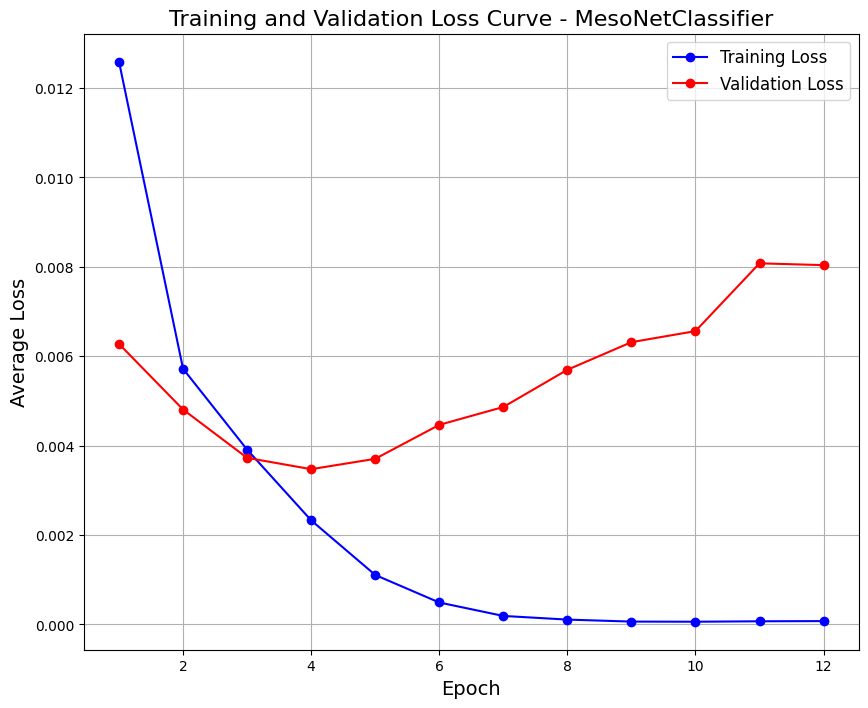

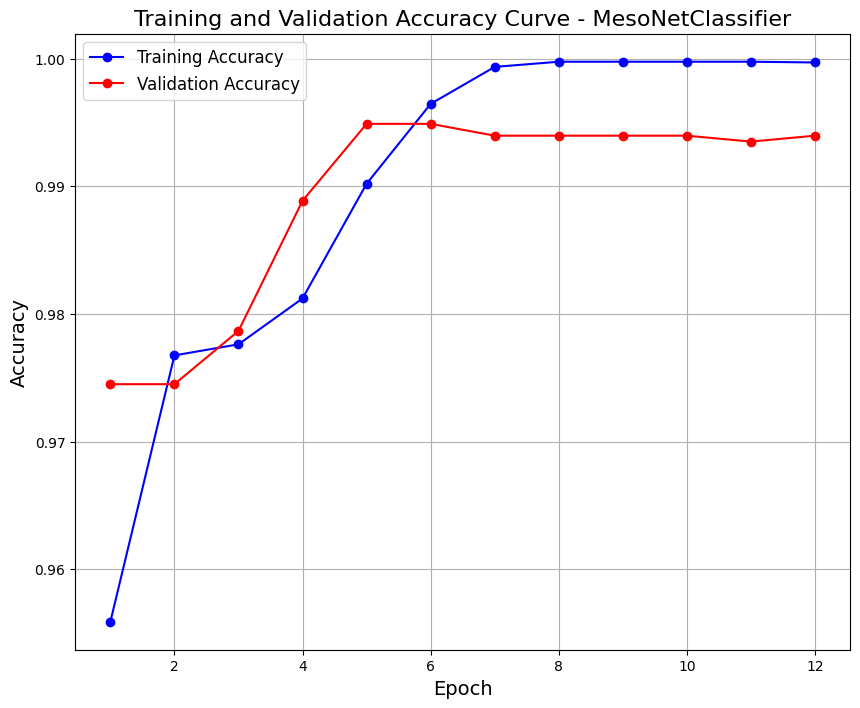

Dataset for test mode: 2157 samples
Class distribution for test mode:
label
1    2114
0      43
Name: count, dtype: int64

MesoNetClassifier Test samples: 0/2157 valid


MesoNetClassifier Evaluating: 100%|██████████| 270/270 [00:37<00:00,  7.23it/s]



MesoNetClassifier Final Test Results:
Test Loss: 0.0038 | AUC: 0.9487
Accuracy: 0.9968 | F1: 0.9983
Precision: 0.9972 | Recall: 0.9995
Confusion Matrix:
[[  37    6]
 [   1 2113]]


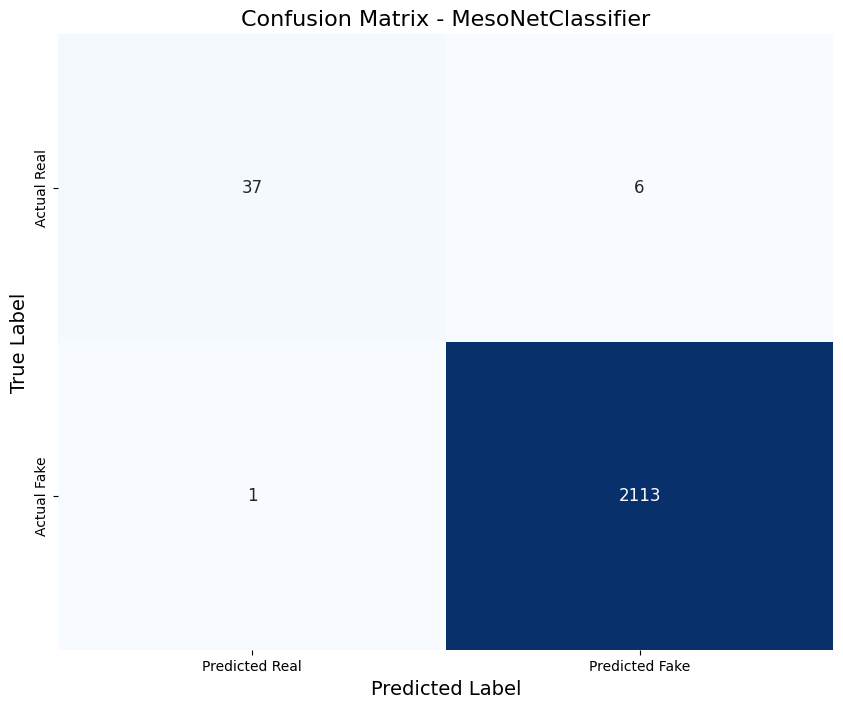

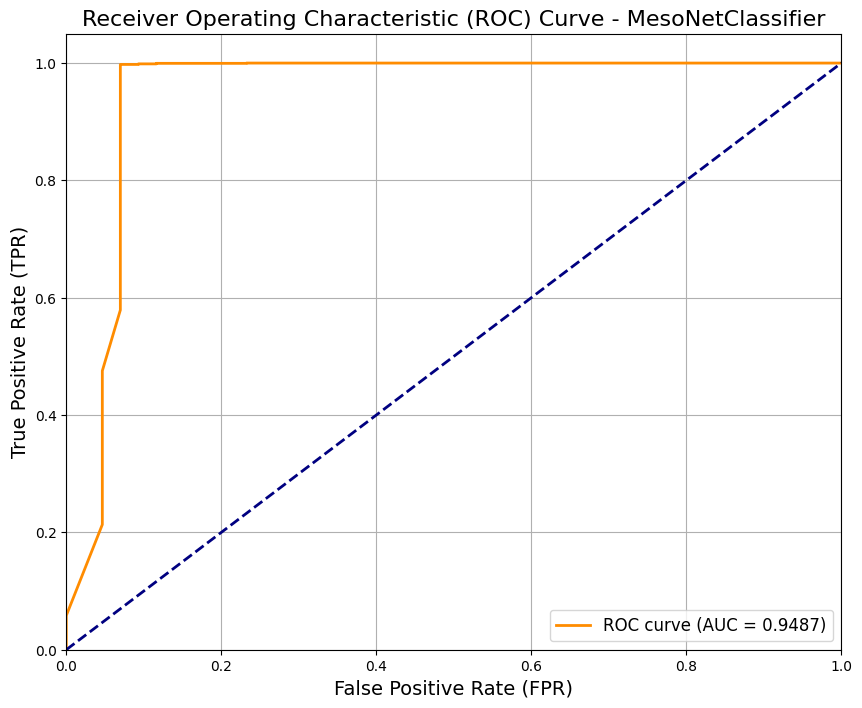


Testing a single video for all models...

Selected video for prediction: /kaggle/input/dataset2/FakeAVCeleb_v1.2/RealVideo-FakeAudio/Asian (South)/women/id00043/00135_fake.mp4

[MesoNetClassifier] Predicting for video: /kaggle/input/dataset2/FakeAVCeleb_v1.2/RealVideo-FakeAudio/Asian (South)/women/id00043/00135_fake.mp4
[MesoNetClassifier] Prediction: Fake (Probability of Fake: 86.04%)
[MesoNetClassifier] True Label: Fake
[MesoNetClassifier] Correct: True
Combined main execution completed


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, precision_recall_fscore_support, roc_curve
from tqdm import tqdm
import warnings
import random
warnings.filterwarnings("ignore")

print("Starting combined main execution...")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class BaseModelTrainer:
    def __init__(self, config, model_class, model_name):
        self.config = config
        self.feature_extractor = FeatureExtractor(config)
        self.model = model_class(config).to(config.DEVICE)
        self.scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
        self.optimizer = optim.AdamW(
            self.model.parameters(),
            lr=config.LEARNING_RATE,
            weight_decay=config.WEIGHT_DECAY
        )
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer,
            T_max=config.NUM_EPOCHS
        )
        self.criterion = FocalLoss(alpha=0.3, gamma=2.5)
        self.best_score = 0
        self.early_stop_counter = 0
        self.model_name = model_name
        self.best_model_path = config.MODEL_SAVE_PATH / f"best_{model_name.lower()}_model.pth"
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        print(f"{model_name} Trainer initialized")

    def train(self, metadata):
        try:
            print(f"Starting training for {self.model_name}")
            train_dataset = DeepfakeDataset(metadata, self.config, self.feature_extractor, 'train')
            train_loader = DataLoader(
                train_dataset,
                batch_size=self.config.BATCH_SIZE,
                shuffle=True,
                num_workers=self.config.NUM_WORKERS,
                pin_memory=True,
                collate_fn=collate_fn
            )
            
            if len(train_dataset) == 0:
                print(f"No training samples available for {self.model_name}")
                return

            print(f"Train samples: {train_dataset.valid_samples}/{len(train_dataset)} valid")
            if train_dataset.error_log:
                print(f"{self.model_name} Train dataset errors (first 5):")
                for i, (idx, err) in enumerate(train_dataset.error_log[:5]):
                    print(f"Error {i+1}: Item {idx}: {err}")

            for epoch in range(self.config.NUM_EPOCHS):
                self.model.train()
                epoch_loss = 0.0
                valid_samples = 0
                train_preds, train_labels = [], []
                progress_bar = tqdm(train_loader, desc=f"{self.model_name} Epoch {epoch+1}")
                
                for batch in progress_bar:
                    if batch is None:
                        print(f"[{self.model_name}] Skipping empty batch")
                        continue
                        
                    visual = batch['visual'].to(self.config.DEVICE, non_blocking=True)
                    audio = batch['audio'].to(self.config.DEVICE, non_blocking=True)
                    labels = batch['label'].to(self.config.DEVICE, non_blocking=True)
                    
                    self.optimizer.zero_grad(set_to_none=True)
                    try:
                        with torch.cuda.amp.autocast():
                            outputs = self.model(visual, audio)
                            loss = self.criterion(outputs, labels)
                        
                        self.scaler.scale(loss).backward()
                        self.scaler.unscale_(self.optimizer)
                        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                        self.scaler.step(self.optimizer)
                        self.scaler.update()
                        
                        batch_size = visual.size(0)
                        epoch_loss += loss.item() * batch_size
                        valid_samples += batch_size
                        
                        # Collect predictions and labels for training accuracy
                        train_preds.extend(torch.sigmoid(outputs).squeeze().detach().cpu().numpy())
                        train_labels.extend(labels.squeeze().detach().cpu().numpy())
                        
                        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
                        
                    except RuntimeError as e:
                        if "out of memory" in str(e):
                            print(f"[{self.model_name}] WARNING: Out of memory, skipping batch")
                            torch.cuda.empty_cache()
                        else:
                            print(f"[{self.model_name}] Error during training: {e}")
                        continue
                    finally:
                        del visual, audio, labels, outputs
                        torch.cuda.empty_cache()

                if valid_samples > 0:
                    epoch_loss /= valid_samples
                    self.train_losses.append(epoch_loss)
                    # Calculate training accuracy
                    train_metrics = self._calculate_metrics(train_preds, train_labels)
                    self.train_accuracies.append(train_metrics['accuracy'])
                    print(f"[{self.model_name}] Epoch {epoch+1}/{self.config.NUM_EPOCHS}, Loss: {epoch_loss:.4f}, Accuracy: {train_metrics['accuracy']:.4f}")
                else:
                    print(f"[{self.model_name}] No valid samples in epoch {epoch+1}")
                    self.train_losses.append(np.nan)
                    self.train_accuracies.append(np.nan)

                val_loss, val_metrics = self._validate(metadata)
                self.val_losses.append(val_loss)
                self.val_accuracies.append(val_metrics['accuracy'])
                print(f"[{self.model_name}] Val Loss: {val_loss:.4f} | Val AUC: {val_metrics['auc']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | Val F1: {val_metrics['f1']:.4f}")
                
                if val_metrics['auc'] > self.best_score:
                    self.best_score = val_metrics['auc']
                    self._save_model()
                    self.early_stop_counter = 0
                else:
                    self.early_stop_counter += 1
                    if self.early_stop_counter >= self.config.PATIENCE:
                        print(f"[{self.model_name}] Early stopping after {epoch+1} epochs")
                        break

                self.scheduler.step()
                
        except Exception as e:
            print(f"[{self.model_name}] Error during training: {e}")
            import traceback
            traceback.print_exc()
        finally:
            torch.cuda.empty_cache()

    def evaluate(self, dataloader):
        self.model.eval()
        val_loss = 0.0
        preds, labels = [], []
        valid_batches = 0
        
        with torch.no_grad():
            progress_bar = tqdm(dataloader, desc=f"{self.model_name} Evaluating")
            for batch in progress_bar:
                if batch is None:
                    print(f"[{self.model_name}] Skipping empty batch in evaluation")
                    continue
                    
                visual = batch['visual'].to(self.config.DEVICE, non_blocking=True)
                audio = batch['audio'].to(self.config.DEVICE, non_blocking=True)
                labels_batch = batch['label'].to(self.config.DEVICE, non_blocking=True)
                
                try:
                    with torch.cuda.amp.autocast():
                        outputs = self.model(visual, audio)
                        loss = self.criterion(outputs, labels_batch)
                    
                    val_loss += loss.item()
                    valid_batches += 1
                    preds.extend(torch.sigmoid(outputs).squeeze().detach().cpu().numpy())
                    labels.extend(labels_batch.squeeze().detach().cpu().numpy())
                    
                except Exception as e:
                    print(f"[{self.model_name}] Error during evaluation: {e}")
                    continue
                finally:
                    del visual, audio, labels_batch
                    if 'outputs' in locals():
                        del outputs
                    torch.cuda.empty_cache()
        
        if valid_batches == 0 or len(preds) == 0:
            print(f"[{self.model_name}] No valid batches in evaluation")
            return 0.0, {
                'auc': 0.0, 'accuracy': 0.0, 'f1': 0.0,
                'confusion_matrix': np.zeros((2,2), dtype=int),
                'precision': 0.0, 'recall': 0.0,
                'roc_curve': ([0, 1], [0, 1], [0, 1])
            }
            
        val_loss /= valid_batches
        metrics = self._calculate_metrics(preds, labels)
        np.save(self.config.MODEL_SAVE_PATH / f"{self.model_name.lower()}_test_preds.npy", np.array(preds))
        np.save(self.config.MODEL_SAVE_PATH / f"{self.model_name.lower()}_test_labels.npy", np.array(labels))
        return val_loss, metrics

    def _validate(self, metadata):
        val_dataset = DeepfakeDataset(metadata, self.config, self.feature_extractor, 'val')
        val_loader = DataLoader(
            val_dataset,
            batch_size=self.config.BATCH_SIZE,
            shuffle=False,
            num_workers=self.config.NUM_WORKERS,
            pin_memory=True,
            collate_fn=collate_fn
        )
        return self.evaluate(val_loader)

    def _calculate_metrics(self, preds, labels):
        preds = np.array(preds)
        labels = np.array(labels)
        binary_preds = (preds > 0.5).astype(int)
        
        try:
            auc = roc_auc_score(labels, preds)
            fpr, tpr, thresholds = roc_curve(labels, preds)
        except Exception as e:
            print(f"[{self.model_name}] Error calculating ROC: {e}")
            auc = 0.0
            fpr, tpr, thresholds = [0, 1], [0, 1], [0, 1]
            
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, binary_preds, average='binary', zero_division=0
        )
        
        return {
            'auc': auc,
            'accuracy': accuracy_score(labels, binary_preds),
            'f1': f1,
            'confusion_matrix': confusion_matrix(labels, binary_preds).astype(int),
            'precision': precision,
            'recall': recall,
            'roc_curve': (fpr, tpr, thresholds)
        }

    def _save_model(self):
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'best_score': self.best_score,
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'train_accuracies': self.train_accuracies,
            'val_accuracies': self.val_accuracies,
            'config': {k: v for k, v in vars(self.config).items() 
                      if not callable(v) and not k.startswith('__')}
        }, self.best_model_path)
        print(f"{self.model_name} saved with best AUC: {self.best_score:.4f}")

    def plot_training_loss(self):
        if not self.train_losses or all(np.isnan(self.train_losses)):
            print(f"[{self.model_name}] No training loss data available")
            return
        plt.figure(figsize=(10, 8))  # Increased figure size
        plt.plot(range(1, len(self.train_losses) + 1), self.train_losses, marker='o', color='blue', label='Training Loss')
        if self.val_losses and not all(np.isnan(self.val_losses)):
            plt.plot(range(1, len(self.val_losses) + 1), self.val_losses, marker='o', color='red', label='Validation Loss')
        plt.xlabel('Epoch', fontsize=14)
        plt.ylabel('Average Loss', fontsize=14)
        plt.title(f'Training and Validation Loss Curve - {self.model_name}', fontsize=16)
        plt.legend(fontsize=12)
        plt.grid(True)
        plt.savefig(self.config.MODEL_SAVE_PATH / f"{self.model_name.lower()}_loss_curve.png")
        plt.show()

    def plot_training_accuracy(self):
        if not self.train_accuracies or all(np.isnan(self.train_accuracies)):
            print(f"[{self.model_name}] No training accuracy data available")
            return
        plt.figure(figsize=(10, 8))  # Increased figure size
        plt.plot(range(1, len(self.train_accuracies) + 1), self.train_accuracies, marker='o', color='blue', label='Training Accuracy')
        if self.val_accuracies and not all(np.isnan(self.val_accuracies)):
            plt.plot(range(1, len(self.val_accuracies) + 1), self.val_accuracies, marker='o', color='red', label='Validation Accuracy')
        plt.xlabel('Epoch', fontsize=14)
        plt.ylabel('Accuracy', fontsize=14)
        plt.title(f'Training and Validation Accuracy Curve - {self.model_name}', fontsize=16)
        plt.legend(fontsize=12)
        plt.grid(True)
        plt.savefig(self.config.MODEL_SAVE_PATH / f"{self.model_name.lower()}_accuracy_curve.png")
        plt.show()

def train_and_evaluate_model(config, metadata_sampled, model_class, model_name):
    print(f"\n=== Training and Evaluating {model_name} ===")
    
    trainer = BaseModelTrainer(config, model_class, model_name)
    
    if trainer.best_model_path.exists():
        try:
            checkpoint = torch.load(trainer.best_model_path, weights_only=False)
            trainer.model.load_state_dict(checkpoint['model_state_dict'])
            trainer.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            trainer.best_score = checkpoint.get('best_score', 0)
            trainer.train_losses = checkpoint.get('train_losses', [])
            trainer.val_losses = checkpoint.get('val_losses', [])
            trainer.train_accuracies = checkpoint.get('train_accuracies', [])
            trainer.val_accuracies = checkpoint.get('val_accuracies', [])
            print(f"Loaded {model_name} with best AUC: {trainer.best_score:.4f}")
        except Exception as e:
            print(f"[{model_name}] Error loading model: {e}")
    
    try:
        trainer.train(metadata_sampled)
    except KeyboardInterrupt:
        print(f"[{model_name}] Training interrupted. Saving current model state...")
        trainer._save_model()
    except Exception as e:
        print(f"[{model_name}] Error during training: {e}")
    
    trainer.plot_training_loss()
    trainer.plot_training_accuracy()
    
    test_loss = 0.0
    test_metrics = {
        'auc': 0.0, 'accuracy': 0.0, 'f1': 0.0,
        'confusion_matrix': np.zeros((2,2), dtype=int),
        'precision': 0.0, 'recall': 0.0,
        'roc_curve': ([0, 1], [0, 1], [0, 1])
    }
    
    try:
        test_dataset = DeepfakeDataset(metadata_sampled, config, trainer.feature_extractor, 'test')
        test_loader = DataLoader(
            test_dataset,
            batch_size=config.BATCH_SIZE,
            shuffle=False,
            num_workers=config.NUM_WORKERS,
            pin_memory=True,
            collate_fn=collate_fn
        )
        
        print(f"\n{model_name} Test samples: {test_dataset.valid_samples}/{len(test_dataset)} valid")
        if test_dataset.error_log:
            print(f"{model_name} Test dataset errors (first 5):")
            for i, (idx, err) in enumerate(test_dataset.error_log[:5]):
                print(f"Error {i+1}: Item {idx}: {err}")
        
        test_loss, test_metrics = trainer.evaluate(test_loader)
    except Exception as e:
        print(f"[{model_name}] Error during evaluation: {e}")
    
    print(f"\n{model_name} Final Test Results:")
    print(f"Test Loss: {test_loss:.4f} | AUC: {test_metrics['auc']:.4f}")
    print(f"Accuracy: {test_metrics['accuracy']:.4f} | F1: {test_metrics['f1']:.4f}")
    print(f"Precision: {test_metrics['precision']:.4f} | Recall: {test_metrics['recall']:.4f}")
    print(f"Confusion Matrix:\n{test_metrics['confusion_matrix']}")
    
    plt.figure(figsize=(10, 8))  # Increased figure size
    sns.heatmap(test_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Real', 'Predicted Fake'],
                yticklabels=['Actual Real', 'Actual Fake'],
                annot_kws={"size": 12})  # Increased annotation font size
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.title(f'Confusion Matrix - {model_name}', fontsize=16)
    plt.savefig(config.MODEL_SAVE_PATH / f"{model_name.lower()}_confusion_matrix.png")
    plt.show()
    
    fpr, tpr, _ = test_metrics['roc_curve']
    plt.figure(figsize=(10, 8))  # Increased figure size
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {test_metrics["auc"]:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=14)
    plt.ylabel('True Positive Rate (TPR)', fontsize=14)
    plt.title(f'Receiver Operating Characteristic (ROC) Curve - {model_name}', fontsize=16)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True)
    plt.savefig(config.MODEL_SAVE_PATH / f"{model_name.lower()}_roc_curve.png")
    plt.show()
    
    return test_metrics, trainer

def predict_single_video(video_path, config, trainer, model_name):
    print(f"\n[{model_name}] Predicting for video: {video_path}")
    try:
        feature_extractor = trainer.feature_extractor
        video_features = feature_extractor.extract_video_features(video_path)
        audio_features = feature_extractor.extract_audio_features(video_path)
        if video_features is None or audio_features is None:
            print(f"[{model_name}] Failed to extract features for {video_path}")
            return None, None, None
        
        visual_feat = video_features['visual']
        if np.isnan(visual_feat).any():
            visual_feat = np.nan_to_num(visual_feat)
        std_val = visual_feat.std(axis=0)
        if not np.all(std_val == 0):
            visual_feat = (visual_feat - visual_feat.mean(axis=0)) / (std_val + 1e-8)
        visual_feat = DeepfakeDataset._pad_or_truncate(visual_feat, config.MAX_FRAMES)
        
        mfcc = audio_features['mfcc']
        if np.isnan(mfcc).any():
            mfcc = np.nan_to_num(mfcc)
        std_val = mfcc.std(axis=1, keepdims=True)
        if not np.all(std_val == 0):
            mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (std_val + 1e-8)
        audio_feat = DeepfakeDataset._pad_or_truncate(mfcc.T, 50)
        
        visual_tensor = torch.FloatTensor(visual_feat).unsqueeze(0).to(config.DEVICE)
        audio_tensor = torch.FloatTensor(audio_feat).unsqueeze(0).to(config.DEVICE)
        
        trainer.model.eval()
        with torch.no_grad():
            with torch.cuda.amp.autocast():
                output = trainer.model(visual_tensor, audio_tensor)
                prob = torch.sigmoid(output).item()
                pred = 1 if prob > 0.5 else 0
        
        true_label = None
        category_map = {
            'RealVideo-RealAudio': 0,
            'RealVideo-FakeAudio': 1,
            'FakeVideo-RealAudio': 1,
            'FakeVideo-FakeAudio': 1
        }
        for category, label in category_map.items():
            if category in str(video_path):
                true_label = label
                break
        
        # Display probability of the predicted class
        prob_display = prob if pred == 1 else (1 - prob)
        label_display = 'Fake' if pred == 1 else 'Real'
        print(f"[{model_name}] Prediction: {label_display} (Probability of {label_display}: {prob_display * 100:.2f}%)")
        if true_label is not None:
            print(f"[{model_name}] True Label: {'Fake' if true_label == 1 else 'Real'}")
            print(f"[{model_name}] Correct: {pred == true_label}")
        
        return pred, prob, true_label
    
    except Exception as e:
        print(f"[{model_name}] Error predicting for {video_path}: {e}")
        return None, None, None

if __name__ == "__main__":
    try:
        set_seed(42)  # Ensure deterministic behavior
        config = Config()
        metadata = pd.read_csv(config.METADATA_FILE)
        metadata = metadata.loc[:, ~metadata.columns.str.contains('^Unnamed')]
        
        print("Available columns in meta_data.csv:", list(metadata.columns))
        print("First 5 rows of metadata:\n", metadata[['path', 'category', 'race', 'gender', 'source']].head().to_string())
        
        required_cols = ['path', 'category', 'race', 'gender', 'source']
        for col in required_cols:
            if col not in metadata.columns:
                raise ValueError(f"Missing required column: {col}")
        
        print("\nValidating first 5 paths:")
        valid_paths = 0
        for idx, row in metadata.head().iterrows():
            category_map = {
                'A': 'RealVideo-RealAudio',
                'B': 'RealVideo-FakeAudio',
                'C': 'FakeVideo-RealAudio',
                'D': 'FakeVideo-FakeAudio'
            }
            root_dir = category_map.get(row['category'], 'FakeVideo-FakeAudio')
            race = row.get('race', 'Unknown')
            gender = row.get('gender', 'men').lower()
            source_id = row.get('source', row.get('target1', 'id00000'))
            dir_path = config.DATASET_PATH / root_dir / race / gender / source_id
            video_path = config.DATASET_PATH / row['path']
            if video_path.suffix == '.mp4' and video_path.exists():
                print(f"Valid path: {video_path}")
                valid_paths += 1
            else:
                video_files = list(dir_path.glob("*.mp4"))
                print(f"Directory {dir_path}: {len(video_files)} .mp4 files found")
                if video_files:
                    valid_paths += 1
        print(f"Path validation: {valid_paths}/5 paths valid")
        
        split_file = config.PROCESSED_DATA_PATH / "metadata_split.csv"
        if not split_file.exists():
            # Sample 500 from each category (with replacement if not enough)
            a_data = metadata[metadata['category'] == 'A'].sample(n=500, random_state=42, replace=True)
            b_data = metadata[metadata['category'] == 'B'].sample(n=500, random_state=42, replace=True)
            c_data = metadata[metadata['category'] == 'C'].sample(n=9709, random_state=42, replace=True)
            d_data = metadata[metadata['category'] == 'D'].sample(n=10857, random_state=42, replace=True)
            metadata_sampled = pd.concat([a_data, b_data, c_data, d_data]).sample(frac=1, random_state=42).reset_index(drop=True)
        
            # Split into train/val/test
            n = len(metadata_sampled)
            train_end = int(0.8 * n)
            val_end = int(0.9 * n)
            metadata_sampled['split'] = ['train'] * train_end + ['val'] * (val_end - train_end) + ['test'] * (n - val_end)
            metadata_sampled = metadata_sampled.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle again
        
            metadata_sampled.to_csv(split_file, index=False)
            print(f"Saved metadata split to {split_file}")
        else:
            metadata_sampled = pd.read_csv(split_file)
            print(f"Loaded metadata split from {split_file}")

        print(f"\nDataset size: {len(metadata_sampled)}")
        print(f"Class distribution:\n{metadata_sampled['category'].value_counts()}")
        print(f"Split distribution:\n{metadata_sampled['split'].value_counts()}")
        
        models = [
            (MesoNetClassifier,     "MesoNetClassifier"),
        ]
        
        print("\nModel Parameter Counts:")
        for model_class, model_name in models:
            model = model_class(config)
            total_params = sum(p.numel() for p in model.parameters())
            print(f"{model_name}: {total_params:,} total parameters")
            del model
            torch.cuda.empty_cache()
        
        trainers = []
        for model_class, model_name in models:
            try:
                test_metrics, trainer = train_and_evaluate_model(config, metadata_sampled, model_class, model_name)
                trainers.append((trainer, model_name))
            except Exception as e:
                print(f"[{model_name}] Error during training/evaluation: {e}")
                import traceback
                traceback.print_exc()
                continue
            finally:
                torch.cuda.empty_cache()
        
        print("\nTesting a single video for all models...")
        test_metadata = metadata_sampled[metadata_sampled['split'] == 'test'].reset_index(drop=True)
        if not test_metadata.empty:
            video_path = Path("/kaggle/input/dataset2/FakeAVCeleb_v1.2/RealVideo-FakeAudio/Asian (South)/women/id00043/00135_fake.mp4")
            if not video_path.exists():
                print(f"Video file not found: {video_path}, falling back to first test video")
                row = test_metadata.iloc[0]
                category_map = {
                    'A': 'RealVideo-RealAudio',
                    'B': 'RealVideo-FakeAudio',
                    'C': 'FakeVideo-RealAudio',
                    'D': 'FakeVideo-FakeAudio'
                }
                root_dir = category_map.get(row['category'], 'FakeVideo-FakeAudio')
                race = row.get('race', 'Unknown')
                gender = row.get('gender', 'men').lower()
                source_id = row.get('source', row.get('target1', 'id00000'))
                dir_path = config.DATASET_PATH / root_dir / race / gender / source_id
                video_path = config.DATASET_PATH / row['path']
                if video_path.suffix == '.mp4' and video_path.exists():
                    print(f"Valid path: {video_path}")
                else:
                    video_files = list(dir_path.glob("*.mp4"))
                    if video_files:
                        video_path = video_files[0]
                        print(f"Selected video file: {video_path}")
            
            if video_path.exists():
                print(f"\nSelected video for prediction: {video_path}")
                for trainer, model_name in trainers:
                    try:
                        if trainer.best_model_path.exists():
                            checkpoint = torch.load(trainer.best_model_path, weights_only=False)
                            trainer.model.load_state_dict(checkpoint['model_state_dict'])
                            predict_single_video(video_path, config, trainer, model_name)
                        else:
                            print(f"[{model_name}] No trained model found, skipping prediction")
                    except Exception as e:
                        print(f"[{model_name}] Error during single video prediction: {e}")
            else:
                print(f"Video file not found: {video_path}")
        else:
            print("No test videos available for single video prediction")
    
    except Exception as e:
        print(f"Error during execution: {e}")
        import traceback
        traceback.print_exc()
    
    print("Combined main execution completed")